In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression as SklearnLR

# Set random seeds for reproducibility
np.random.seed(42)

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [2]:
class LinearRegression:
    """
    Linear Regression with Gradient Descent (NumPy only)

    y = X * w + b
    Loss = (1/n) * sum((y_pred - y_true)^2)
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

        # Gradient descent
        for i in range(self.n_iterations):
            # Forward pass: predict
            y_pred = np.dot(X, self.weights) + self.bias

            # Compute loss
            error = y_pred - y
            loss = (1 / n_samples) * np.sum(error ** 2)
            self.loss_history.append(loss)

            # Compute gradients
            # dL/dw = (2/n) * X^T * error
            # dL/db = (2/n) * sum(error)
            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Print progress
            if i % 200 == 0:
                print(f"  Iteration {i:4d}: Loss = {loss:.6f}")

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def get_params(self):
        return {'weights': self.weights, 'bias': self.bias}

In [3]:
# Load California Housing dataset
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

print("=" * 50)
print("CALIFORNIA HOUSING DATASET")
print("=" * 50)
print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]} ({', '.join(feature_names)})")
print(f"Target: Median House Value ($100,000s)")
print(f"\nTarget range: ${y.min()*100000:.0f} - ${y.max()*100000:.0f}")

# Quick stats
df = pd.DataFrame(X, columns=feature_names)
df['Price'] = y
print("\n" + "=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
print(df.describe().round(2))

CALIFORNIA HOUSING DATASET
Samples: 20640
Features: 8 (MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude)
Target: Median House Value ($100,000s)

Target range: $14999 - $500001

SUMMARY STATISTICS
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude     Price  
count  20640.00   20640.00  20640.00  
mean      35.63    -119.57      2.07  
std   

In [4]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

# Scale (CRITICAL for gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Don't fit on test data!

print("\nAfter scaling:")
print(f"Train mean: {X_train_scaled.mean():.6f} (should be ~0)")
print(f"Train std:  {X_train_scaled.std():.6f} (should be ~1)")

Train: 16512 samples
Test:  4128 samples

After scaling:
Train mean: -0.000000 (should be ~0)
Train std:  1.000000 (should be ~1)


In [5]:
print("=" * 50)
print("TRAINING CUSTOM MODEL")
print("=" * 50)

model = LinearRegression(learning_rate=0.01, n_iterations=1000)
model.fit(X_train_scaled, y_train)

print(f"\nFinal Training Loss: {model.loss_history[-1]:.6f}")

TRAINING CUSTOM MODEL
  Iteration    0: Loss = 5.627997
  Iteration  200: Loss = 0.596321
  Iteration  400: Loss = 0.559027
  Iteration  600: Loss = 0.540214
  Iteration  800: Loss = 0.530171

Final Training Loss: 0.524776


In [6]:
# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Train R²:  {train_r2:.4f}")
print(f"Test R²:   {test_r2:.4f}")
print(f"Test MSE:  {test_mse:.4f}")
print(f"Test RMSE: ${test_rmse*100000:.0f}")
print(f"\n(Mean house price: ${y.mean()*100000:.0f})")

MODEL PERFORMANCE
Train R²:  0.6074
Test R²:   0.5766
Test MSE:  0.5548
Test RMSE: $74488

(Mean house price: $206856)


In [7]:
# sklearn model (uses normal equation, not gradient descent)
sk_model = SklearnLR()
sk_model.fit(X_train_scaled, y_train)
sk_pred = sk_model.predict(X_test_scaled)
sk_r2 = r2_score(y_test, sk_pred)

print("=" * 50)
print("COMPARISON")
print("=" * 50)
print(f"Your model R²:  {test_r2:.4f}")
print(f"sklearn R²:     {sk_r2:.4f}")
print(f"Difference:     {abs(test_r2 - sk_r2):.6f}")
print("\n(They should be very close!)")

COMPARISON
Your model R²:  0.5766
sklearn R²:     0.5758
Difference:     0.000800

(They should be very close!)


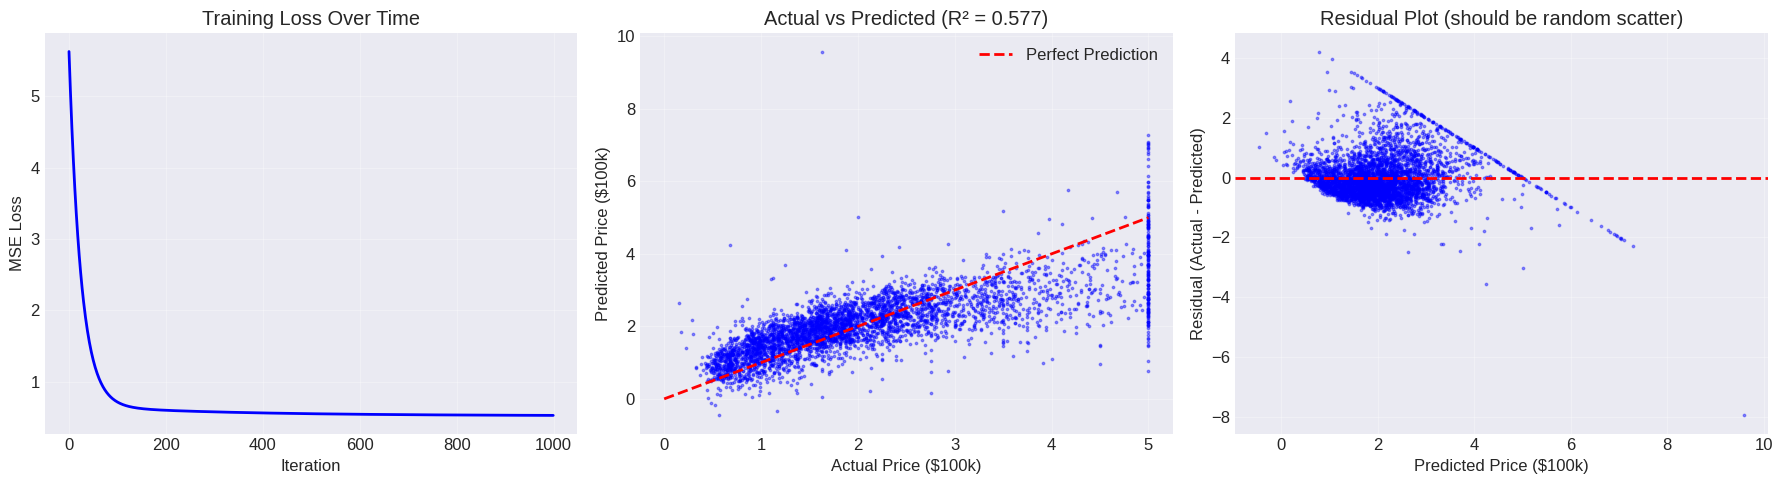

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss Curve
axes[0].plot(model.loss_history, color='blue', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss Over Time')
axes[0].grid(True, alpha=0.3)

# 2. Predictions vs Actual
axes[1].scatter(y_test, y_test_pred, alpha=0.4, s=3, color='blue')
axes[1].plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($100k)')
axes[1].set_ylabel('Predicted Price ($100k)')
axes[1].set_title(f'Actual vs Predicted (R² = {test_r2:.3f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Residuals
residuals = y_test - y_test_pred
axes[2].scatter(y_test_pred, residuals, alpha=0.4, s=3, color='blue')
axes[2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Predicted Price ($100k)')
axes[2].set_ylabel('Residual (Actual - Predicted)')
axes[2].set_title('Residual Plot (should be random scatter)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE (by coefficient magnitude)
  MedInc              : +0.8595  █████████████████████████████████████████████████████████████████████████████████████
  Latitude            : -0.6792  ███████████████████████████████████████████████████████████████████
  Longitude           : -0.6503  █████████████████████████████████████████████████████████████████
  AveBedrms           : +0.2829  ████████████████████████████
  AveRooms            : -0.2550  █████████████████████████
  HouseAge            : +0.1505  ███████████████
  AveOccup            : -0.0435  ████
  Population          : +0.0072  


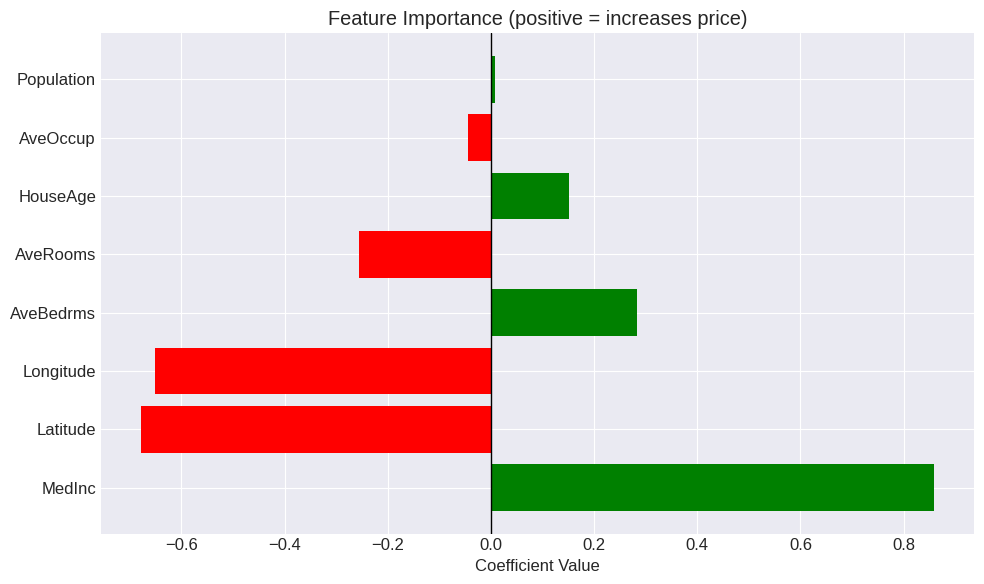

In [9]:
# Your model's coefficients
weights = model.weights

# Sort by absolute importance
indices = np.argsort(np.abs(weights))[::-1]

print("=" * 50)
print("FEATURE IMPORTANCE (by coefficient magnitude)")
print("=" * 50)
for i in indices:
    bar = "█" * int(abs(weights[i]) * 100)
    print(f"  {feature_names[i]:20s}: {weights[i]:+.4f}  {bar}")

plt.figure(figsize=(10, 6))
colors = ['green' if w > 0 else 'red' for w in weights[indices]]
plt.barh(range(len(indices)), weights[indices], color=colors)
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (positive = increases price)')
plt.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

LEARNING RATE EXPERIMENT
  Iteration    0: Loss = 5.630650
  Iteration  200: Loss = 2.873355
  Iteration  400: Loss = 1.639438
  Iteration    0: Loss = 5.647371
  Iteration  200: Loss = 0.594868
  Iteration  400: Loss = 0.558130
  Iteration    0: Loss = 5.643098
  Iteration  200: Loss = 0.524614
  Iteration  400: Loss = 0.518405
  Iteration    0: Loss = 5.623785
  Iteration  200: Loss = 0.518371
  Iteration  400: Loss = 0.517939
  Iteration    0: Loss = 5.616496
  Iteration  200: Loss = 61.424018
  Iteration  400: Loss = 1236478.895540


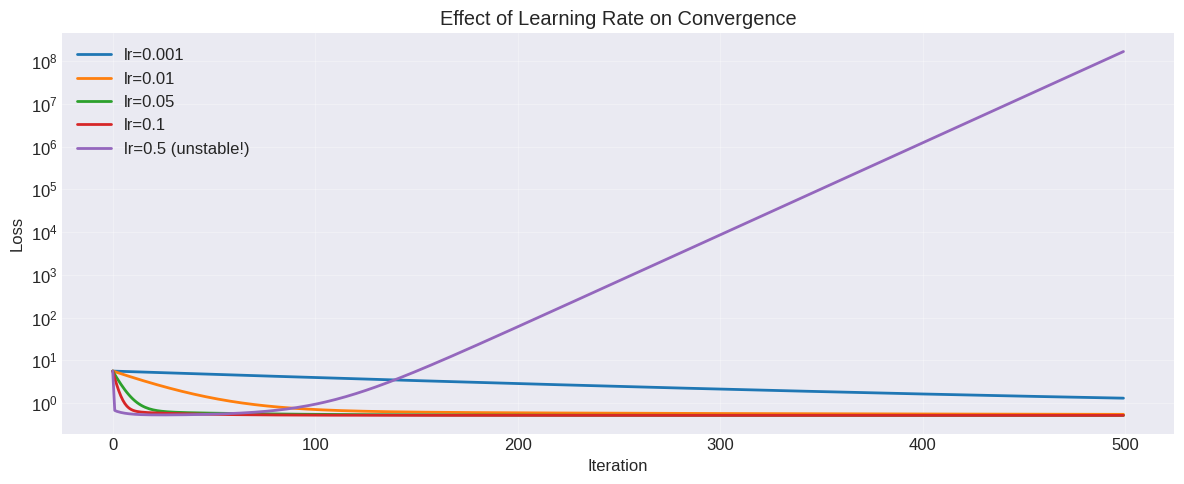

In [10]:
print("=" * 50)
print("LEARNING RATE EXPERIMENT")
print("=" * 50)

lrs = [0.001, 0.01, 0.05, 0.1, 0.5]
plt.figure(figsize=(12, 5))

for lr in lrs:
    model_exp = LinearRegression(learning_rate=lr, n_iterations=500)
    model_exp.fit(X_train_scaled, y_train)
    label = f'lr={lr}'
    if lr == 0.5:
        label += ' (unstable!)'
    plt.plot(model_exp.loss_history, linewidth=2, label=label)

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

  Iteration    0: Loss = 5.631553
  Iteration  200: Loss = 0.596701
  Iteration  400: Loss = 0.559151
  Iteration  600: Loss = 0.540242
  Iteration  800: Loss = 0.530161
Degree 1 -> 8 features: Train R²=0.6075, Test R²=0.5767
  Iteration    0: Loss = 5.609833
  Iteration  200: Loss = 0.544484
  Iteration  400: Loss = 0.515409
  Iteration  600: Loss = 0.505716
  Iteration  800: Loss = 0.501154
Degree 2 -> 8 features: Train R²=0.6272, Test R²=0.5819
  Iteration    0: Loss = 5.651282
  Iteration  200: Loss = 0.502312
  Iteration  400: Loss = 0.482809
  Iteration  600: Loss = 0.475047
  Iteration  800: Loss = 0.470075
Degree 3 -> 8 features: Train R²=0.6512, Test R²=0.3771


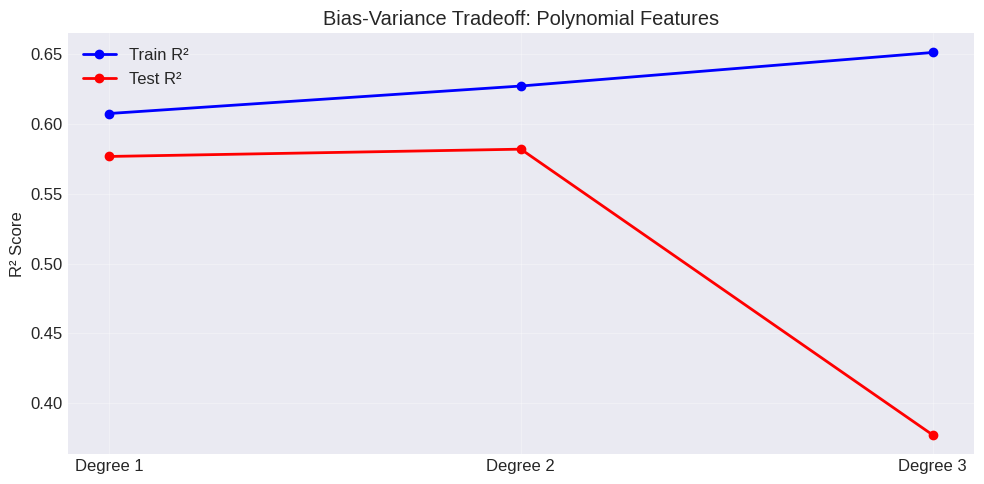


If Test R² drops while Train R² increases = OVERFITTING


In [11]:
from sklearn.preprocessing import PolynomialFeatures

# Try degree 1 (original), 2, 3
degrees = [1, 2, 3]
train_r2_scores = []
test_r2_scores = []

for deg in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Scale
    scaler_poly = StandardScaler()
    X_train_poly_s = scaler_poly.fit_transform(X_train_poly)
    X_test_poly_s = scaler_poly.transform(X_test_poly)

    # Train
    model_poly = LinearRegression(learning_rate=0.01, n_iterations=1000)
    model_poly.fit(X_train_poly_s, y_train)

    # Evaluate
    train_r2 = r2_score(y_train, model_poly.predict(X_train_poly_s))
    test_r2 = r2_score(y_test, model_poly.predict(X_test_poly_s))

    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

    print(f"Degree {deg} -> {X_train.shape[1]} features: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}")

# Plot
plt.figure(figsize=(10, 5))
x_plot = range(len(degrees))
plt.plot(x_plot, train_r2_scores, 'bo-', linewidth=2, label='Train R²')
plt.plot(x_plot, test_r2_scores, 'ro-', linewidth=2, label='Test R²')
plt.xticks(x_plot, [f'Degree {d}' for d in degrees])
plt.ylabel('R² Score')
plt.title('Bias-Variance Tradeoff: Polynomial Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nIf Test R² drops while Train R² increases = OVERFITTING")